# Example 7: Ground-Station Orbit Determination for a Lunar Satellite

This tutorial estimates a lunar satellite trajectory from Earth-based range and range-rate tracking. It introduces LuPNT's batch least-squares orbit-determination workflow using three Deep Space Network complexes: Goldstone (`DSS14`), Canberra (`DSS43`), and Madrid (`DSS63`), then refines the solution with a **square-root information filter (SRIF) and smoother**.

The measurement model is the classic two-way tracking pair:

$$
\rho = \|\mathbf r_{sc}-\mathbf r_{gs}\| + \epsilon_\rho, \qquad
\dot\rho = \hat{\boldsymbol\rho}\cdot(\mathbf v_{sc}-\mathbf v_{gs}) + \epsilon_{\dot\rho}.
$$

LuPNT's C++ `GroundStationOdtsSimulation` performs truth propagation, visibility checks, measurement simulation, and iterative weighted least squares. The design matrix is built analytically: range/range-rate partials are chained with the state-transition matrix $\Phi(t_i,t_0)$ from `NBodyDynamics::Propagate`, rather than by finite differencing.

Workflow:

1. configure the ELFO, force model, DSN stations, and measurement noise;
2. generate visibility windows and synthetic observations;
3. run the batch filter;
4. inspect convergence, residuals, and formal covariance;
5. rotate the final trajectory error into the RTN frame for interpretation;
6. run the **SRIF + Dyer–McReynolds smoother** (`lupnt/numerics/filters/srif.h`) to obtain a numerically-robust, process-noise-aware per-epoch covariance that is more realistic — less optimistic — than propagating the batch epoch covariance forward.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import os, sys
from pathlib import Path

# Use THIS repo's pylupnt/data, not a stale copy on a global PYTHONPATH (~/.zshrc) or kernelspec.
for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

[00.02][PyLuPNT] Initializing


## 1. Configure the Simulation

`GroundStationOdtsConfig` bundles everything the C++ simulation needs: the ELFO
orbital elements, force model, ground-station network, simulation timing,
measurement noise, the a-priori state-error to inject into the batch filter's
starting guess, and the batch filter's own settings. Defaults already match
Example 1's ELFO and the DSN 70 m subnet (`pnt.default_dsn_stations()`); we only
override the fields we want to highlight.

In [2]:
cfg = pnt.GroundStationOdtsConfig()

# ELFO (same frozen orbit as Example 1), Moon-centered Orbital-Plane frame.
cfg.start_epoch_utc = "2026-01-01T00:00:00"
cfg.orbit_a_m = 6541.4e3
cfg.orbit_ecc = 0.6
cfg.orbit_inc_rad = 56.2 * pnt.RAD
cfg.orbit_raan_rad = 0.0
cfg.orbit_argp_rad = 90.0 * pnt.RAD
cfg.orbit_mean_anomaly_rad = 0.0

# Force model: 2x2 Moon gravity + Earth/Sun third-body + SRP (matches Example 1).
cfg.moon_gravity_degree = 2
cfg.moon_gravity_order = 2
cfg.include_earth = True
cfg.include_sun = True
cfg.use_srp = True
cfg.srp_cr, cfg.srp_area_m2, cfg.srp_mass_kg = 1.8, 0.02, 10.0

# DSN 70 m ground stations (Goldstone / Canberra / Madrid) and visibility.
cfg.ground_stations = pnt.default_dsn_stations()
cfg.elevation_mask_deg = 10.0

# Simulation timing: 36 hours (~2.7 orbits) at a 5-minute observation cadence.
cfg.duration_s = 36.0 * 3600.0
cfg.obs_interval_s = 300.0

# Measurement noise (representative DSN coherent ranging/Doppler precision).
cfg.use_range = True
cfg.use_range_rate = True
cfg.range_sigma_m = 10.0
cfg.range_rate_sigma_mps = 1.0e-3

# Deliberately poor a-priori state (~km-level position, ~0.5 m/s velocity error),
# sampled ~ N(0, sigma^2) and seeded by cfg.seed for reproducibility.
cfg.initial_position_sigma_m = 2000.0
cfg.initial_velocity_sigma_mps = 0.5
cfg.seed = 42

# Batch (iterative weighted-least-squares) filter.
cfg.batch_max_iterations = 10
cfg.batch_convergence_tol = 1.0e-3
cfg.batch_use_initialization = False
# Build the batch design matrix analytically (autodiff state-transition matrix +
# closed-form range/range-rate partials) instead of by finite differencing. This is
# the default; set it False to fall back to the legacy numerical Jacobian.
cfg.batch_use_analytic_jacobian = True

# Square-root information filter (SRIF) + Dyer-McReynolds smoother, run after the
# batch as a numerically-robust, process-noise-aware post-processor (Sections 8-9).
# It re-uses the same measurements and diffuse a-priori as the batch, but injects a
# small white-noise-acceleration process noise (per-axis PSD [m^2/s^3]) to account
# for unmodeled dynamics -- so its per-epoch covariance is more realistic than the
# batch's Phi P Phi^T mapping. Setting srif_use_process_noise = False makes the SRIF
# a pure square-root batch whose smoother reproduces the batch solution exactly.
cfg.run_srif = True
cfg.srif_use_process_noise = True
cfg.srif_accel_psd = 3.0e-13

for lla in cfg.ground_stations:
    print(
        f"{lla.name:20s}  lat={lla.latitude_deg:7.3f}  lon={lla.longitude_deg:7.3f}  "
        f"alt={lla.altitude_m:6.1f} m"
    )

DSS14 (Goldstone)     lat= 35.426  lon=243.110  alt=1001.4 m
DSS43 (Canberra)      lat=-35.402  lon=148.981  alt= 688.9 m
DSS63 (Madrid)        lat= 40.431  lon=355.752  alt= 864.8 m


## 2. Run the Simulation

`run()` cascades through `setup() -> precompute() -> run()` automatically: it builds
the truth trajectory and dynamics, runs the visibility analysis, simulates noisy
range/range-rate measurements, and then hands them to `lupnt::RunBatchFilter`.

In [3]:
sim = pnt.GroundStationOdtsSimulation(cfg)
sim.run()
results = sim.get_results()

t_hrs = (results.t_tdb - results.t_tdb[0]) / pnt.SECS_HOUR
station_colors = {
    "DSS14 (Goldstone)": "steelblue",
    "DSS43 (Canberra)": "darkorange",
    "DSS63 (Madrid)": "seagreen",
}

print(f"Epochs: {len(results.t_tdb)}   Measurements: {len(results.obs_epoch_index)}")
print(f"Converged: {results.converged}   Iterations: {results.num_iterations}")

Epochs: 433   Measurements: 629
Converged: True   Iterations: 5


## 3. Visibility Analysis

`results.elevation_deg` is the topocentric elevation of the satellite as seen from
each station, evaluated on the full simulation grid; the 10&deg; mask used to select
tracking measurements is overlaid.

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_11490/3352937913.py:23: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  plt.tight_layout()


/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


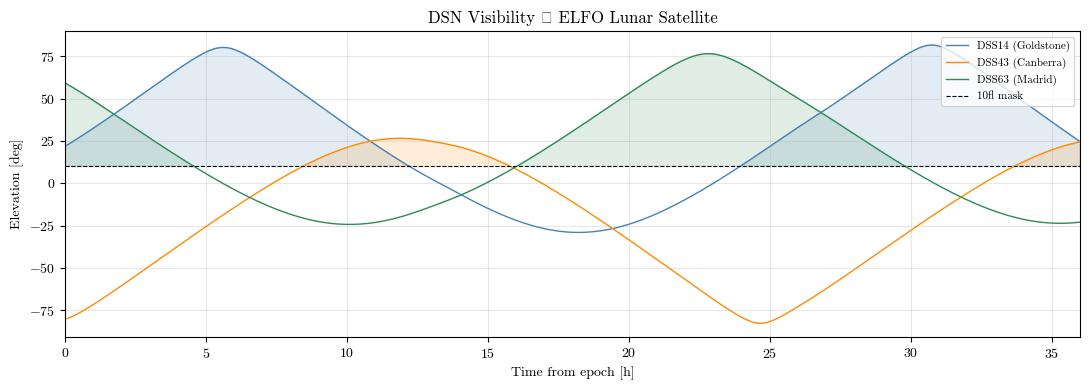

DSS14 (Goldstone)      292/433 epochs visible ( 67.4%)
DSS43 (Canberra)       117/433 epochs visible ( 27.0%)
DSS63 (Madrid)         220/433 epochs visible ( 50.8%)


In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for j, name in enumerate(results.station_names):
    el = results.elevation_deg[:, j]
    vis = el > cfg.elevation_mask_deg
    color = station_colors.get(name, f"C{j}")
    ax.plot(t_hrs, el, lw=1.0, color=color, label=name)
    ax.fill_between(
        t_hrs, el, cfg.elevation_mask_deg, where=vis, color=color, alpha=0.15
    )
ax.axhline(
    cfg.elevation_mask_deg,
    color="k",
    ls="--",
    lw=0.8,
    label=f"{cfg.elevation_mask_deg:.0f}\N{DEGREE SIGN} mask",
)
ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel("Elevation [deg]")
ax.set_title("DSN Visibility — ELFO Lunar Satellite")
ax.set_xlim(0, t_hrs[-1])
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for j, name in enumerate(results.station_names):
    n_vis = int(np.sum(results.elevation_deg[:, j] > cfg.elevation_mask_deg))
    print(
        f"{name:20s}  {n_vis:4d}/{len(t_hrs)} epochs visible "
        f"({100 * n_vis / len(t_hrs):5.1f}%)"
    )

## 4. Simulated Range and Range-Rate Measurements

Each measurement is tagged with an epoch index (into `results.t_tdb`) and a station
index (into `results.station_names`).

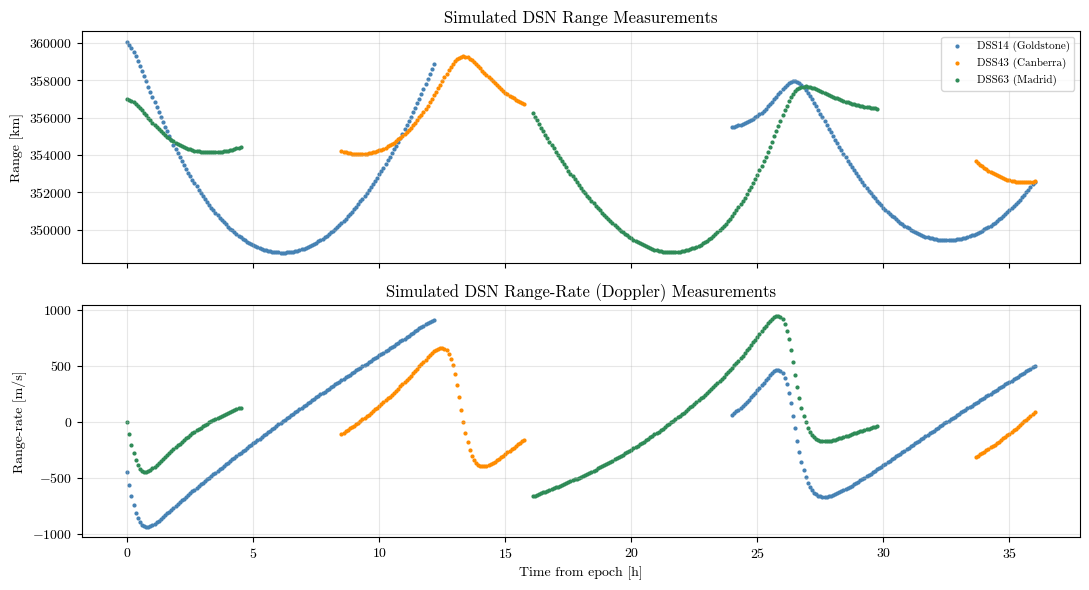

In [5]:
obs_t_hrs = t_hrs[results.obs_epoch_index]
obs_station_names = [results.station_names[s] for s in results.obs_station_index]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for name in results.station_names:
    mask = [s == name for s in obs_station_names]
    color = station_colors.get(name, "gray")
    axes[0].scatter(
        obs_t_hrs[mask], results.obs_range_m[mask] / 1e3, s=4, color=color, label=name
    )
    axes[1].scatter(obs_t_hrs[mask], results.obs_range_rate_mps[mask], s=4, color=color)

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Simulated DSN Range Measurements")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_xlabel("Time from epoch [h]")
axes[1].set_title("Simulated DSN Range-Rate (Doppler) Measurements")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Batch Filter Convergence

`results.iteration_*` arrays record one entry per batch-filter iteration (from
`BatchFilterResults::iteration_history` in `lupnt/numerics/filters/batch_filter.h`):
the state estimate at the *start* of the iteration, the correction norm applied,
the weighted RMS residual (dimensionless, normalized by each measurement's own
noise sigma), and -- computed here from the logged state -- position/velocity
error against truth and per-measurement-type RMS residuals.

In [6]:
pos0 = np.linalg.norm(results.x0_initial_guess[:3] - results.x0_true[:3])
vel0 = np.linalg.norm(results.x0_initial_guess[3:] - results.x0_true[3:])
print(f"Initial position error: {pos0:.1f} m   Initial velocity error: {vel0:.3f} m/s")
print()
for k in range(results.num_iterations):
    print(
        f"iter {k}: rms(rho)={results.iteration_rms_range_m[k]:8.3f} m  "
        f"rms(rho_dot)={results.iteration_rms_range_rate_mps[k]:9.6f} m/s  "
        f"|pos_err|={results.iteration_pos_error_m[k]:9.3f} m  "
        f"|vel_err|={results.iteration_vel_error_mps[k]:9.6f} m/s  "
        f"weighted_rms={results.iteration_weighted_rms[k]:8.3f}"
    )

Initial position error: 1149.0 m   Initial velocity error: 0.468 m/s

iter 0: rms(rho)=116348.014 m  rms(rho_dot)=28.516640 m/s  |pos_err|= 1149.038 m  |vel_err|= 0.467796 m/s  weighted_rms=21778.055
iter 1: rms(rho)=12744.612 m  rms(rho_dot)= 1.119698 m/s  |pos_err|=15986.924 m  |vel_err|=10.383792 m/s  weighted_rms=1199.578
iter 2: rms(rho)=1620.023 m  rms(rho_dot)= 0.390740 m/s  |pos_err|=   21.245 m  |vel_err|= 0.039472 m/s  weighted_rms= 299.100
iter 3: rms(rho)=  10.169 m  rms(rho_dot)= 0.001080 m/s  |pos_err|=    5.627 m  |vel_err|= 0.003292 m/s  weighted_rms=   1.049
iter 4: rms(rho)=  10.003 m  rms(rho_dot)= 0.001047 m/s  |pos_err|=    2.737 m  |vel_err|= 0.001364 m/s  weighted_rms=   1.024


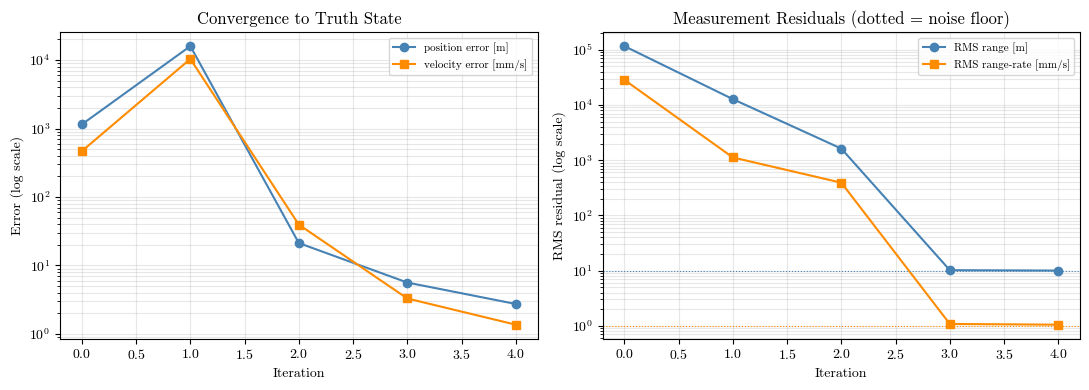

In [7]:
iters = np.arange(results.num_iterations)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(
    iters,
    results.iteration_pos_error_m,
    "o-",
    color="steelblue",
    label="position error [m]",
)
axes[0].semilogy(
    iters,
    results.iteration_vel_error_mps * 1e3,
    "s-",
    color="darkorange",
    label="velocity error [mm/s]",
)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Error (log scale)")
axes[0].set_title("Convergence to Truth State")
axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(
    iters, results.iteration_rms_range_m, "o-", color="steelblue", label="RMS range [m]"
)
axes[1].semilogy(
    iters,
    results.iteration_rms_range_rate_mps * 1e3,
    "s-",
    color="darkorange",
    label="RMS range-rate [mm/s]",
)
axes[1].axhline(cfg.range_sigma_m, color="steelblue", ls=":", lw=0.8)
axes[1].axhline(cfg.range_rate_sigma_mps * 1e3, color="darkorange", ls=":", lw=0.8)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("RMS residual (log scale)")
axes[1].set_title("Measurement Residuals (dotted = noise floor)")
axes[1].legend(fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Final solution and formal covariance

The batch solution is an estimated Cartesian state at the reference epoch plus its covariance. The diagonal square roots give the formal 1-sigma uncertainty in the solved-for state components. These numbers are local to the chosen epoch; the next section propagates the covariance along the full arc.

In [8]:
sigma = np.sqrt(np.diag(results.covariance))

print("Estimated epoch state (MCI frame):")
print(f"  r0 = {results.x0_estimated[:3]} m")
print(f"  v0 = {results.x0_estimated[3:]} m/s")
print()

pos_err = np.linalg.norm(results.x0_estimated[:3] - results.x0_true[:3])
vel_err = np.linalg.norm(results.x0_estimated[3:] - results.x0_true[3:])
print(
    f"Final position error vs. truth: {pos_err:.3f} m "
    f"(formal 1-sigma: {np.linalg.norm(sigma[:3]):.3f} m)"
)
print(
    f"Final velocity error vs. truth: {vel_err:.6f} m/s "
    f"(formal 1-sigma: {np.linalg.norm(sigma[3:]):.6f} m/s)"
)

Estimated epoch state (MCI frame):
  r0 = [ 410806.86228458  178480.17910345 2577939.40559239] m
  v0 = [-1636.08688181   520.33127494   224.69320414] m/s

Final position error vs. truth: 2.737 m (formal 1-sigma: 1.872 m)
Final velocity error vs. truth: 0.001364 m/s (formal 1-sigma: 0.000969 m/s)


## 7. Estimate Error in the RTN Frame with Formal Covariance

Rather than overlaying the truth and estimated orbits (which look identical at this
scale), we look at the **estimate error** `estimated_state - truth_state` expressed in
the satellite's **RTN frame** (Radial / Transverse / Normal, defined by the *true*
orbit at each epoch), together with the propagated formal **1-σ covariance**.

The covariance is mapped from the epoch solution to every point on the arc with the
same autodiff state-transition matrix used by the batch filter's analytic Jacobian:
`P(t_i) = Φ(t_i, t_0) · P_0 · Φ(t_i, t_0)ᵀ` (`results.estimated_covariance`, one
row-major-flattened 6×6 block per epoch, in MCI). Both the error and the covariance
are rotated into RTN by `Q_i = [R̂ T̂ N̂]ᵀ`, with

```
R̂ = r / |r|            (radial)
N̂ = (r × v) / |r × v|  (orbit normal)
T̂ = N̂ × R̂             (transverse / along-track)
```

Plotting the RTN error components against their ±1-σ bounds over the whole arc shows
**where on the orbit the solution is best constrained** — the error and the covariance
tube both shrink near tracking passes and around periapsis, and widen through the
long, poorly-observed apoapsis coast.

In [9]:
# RTN frame from the TRUE orbit at each epoch: rows of Q_i are [R_hat, T_hat, N_hat],
# so Q_i @ x_mci gives the vector's radial / transverse / normal components.
r_true = results.truth_state[:, :3]
v_true = results.truth_state[:, 3:]
R_hat = r_true / np.linalg.norm(r_true, axis=1, keepdims=True)
h = np.cross(r_true, v_true)
N_hat = h / np.linalg.norm(h, axis=1, keepdims=True)
T_hat = np.cross(N_hat, R_hat)
Q = np.stack([R_hat, T_hat, N_hat], axis=1)  # [N, 3, 3]

# Estimate error (estimated - truth), rotated into RTN.
dpos_mci = results.estimated_state[:, :3] - results.truth_state[:, :3]
dvel_mci = results.estimated_state[:, 3:] - results.truth_state[:, 3:]
dpos_rtn = np.einsum("nij,nj->ni", Q, dpos_mci)
dvel_rtn = np.einsum("nij,nj->ni", Q, dvel_mci)

# Formal covariance propagated over the arc (MCI), rotated into RTN: P_rtn = Q P Qᵀ.
cov = results.estimated_covariance.reshape(-1, 6, 6)
Prr_rtn = np.einsum("nij,njk,nlk->nil", Q, cov[:, :3, :3], Q)
Pvv_rtn = np.einsum("nij,njk,nlk->nil", Q, cov[:, 3:, 3:], Q)
sig_pos_rtn = np.sqrt(np.diagonal(Prr_rtn, axis1=1, axis2=2))  # [N, 3] 1-sigma [m]
sig_vel_rtn = np.sqrt(np.diagonal(Pvv_rtn, axis1=1, axis2=2))  # [N, 3] 1-sigma [m/s]

# True-orbit radius, to mark periapsis/apoapsis on the error plots.
r_mag = np.linalg.norm(r_true, axis=1)

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_11490/1909619474.py:52: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()


/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


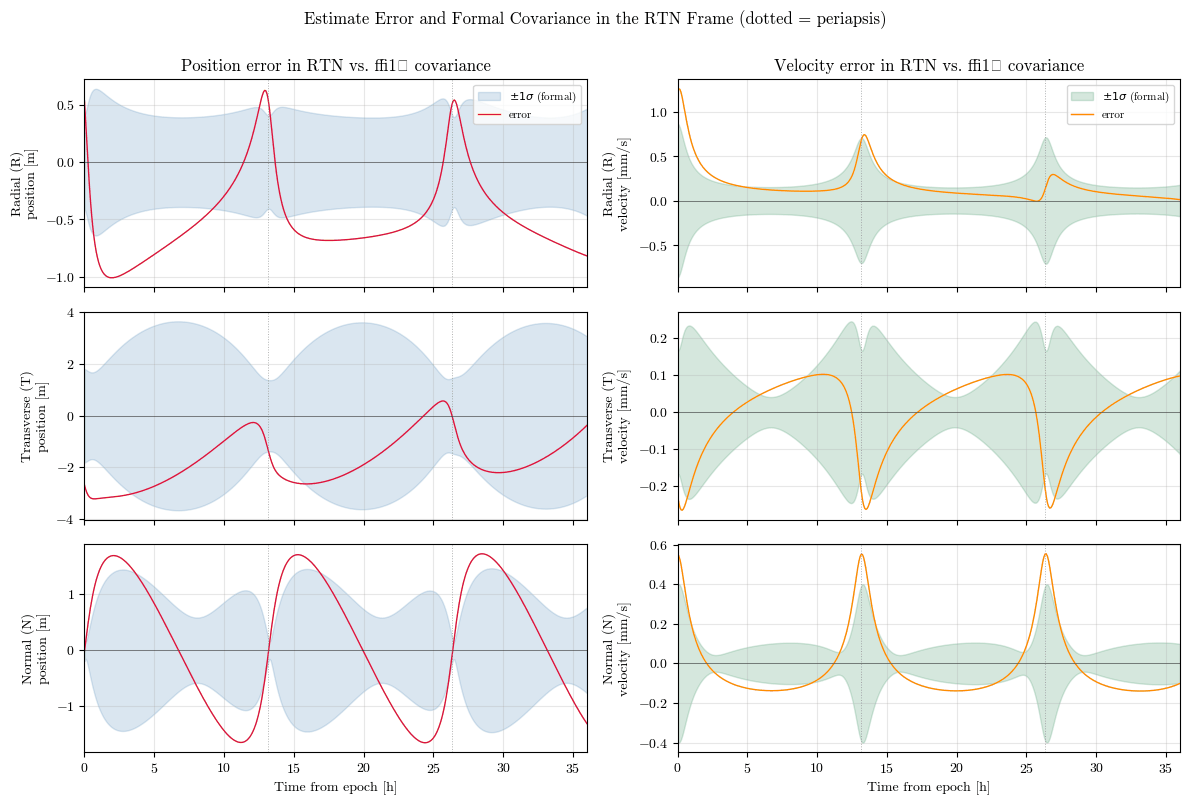

Smallest position error:  0.514 m at t = 26.33 h (orbit radius  2626.6 km)
Largest  position error:  3.711 m at t =  1.83 h (orbit radius  6148.4 km)


In [10]:
labels = ["Radial (R)", "Transverse (T)", "Normal (N)"]
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)

for k in range(3):
    # Position error + 1-sigma covariance tube.
    axp = axes[k, 0]
    axp.fill_between(
        t_hrs,
        -sig_pos_rtn[:, k],
        sig_pos_rtn[:, k],
        color="steelblue",
        alpha=0.20,
        label=r"$\pm 1\sigma$ (formal)",
    )
    axp.plot(t_hrs, dpos_rtn[:, k], color="crimson", lw=1.0, label="error")
    axp.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axp.set_ylabel(f"{labels[k]}\nposition [m]")
    axp.grid(True, alpha=0.3)

    # Velocity error + 1-sigma covariance tube.
    axv = axes[k, 1]
    axv.fill_between(
        t_hrs,
        -sig_vel_rtn[:, k] * 1e3,
        sig_vel_rtn[:, k] * 1e3,
        color="seagreen",
        alpha=0.20,
        label=r"$\pm 1\sigma$ (formal)",
    )
    axv.plot(t_hrs, dvel_rtn[:, k] * 1e3, color="darkorange", lw=1.0, label="error")
    axv.axhline(0.0, color="k", lw=0.6, alpha=0.5)
    axv.set_ylabel(f"{labels[k]}\nvelocity [mm/s]")
    axv.grid(True, alpha=0.3)

# Mark periapsis passages (radius minima) — where geometry/observability is strongest.
peri = np.where((r_mag[1:-1] < r_mag[:-2]) & (r_mag[1:-1] < r_mag[2:]))[0] + 1
for ax in axes.ravel():
    for p in peri:
        ax.axvline(t_hrs[p], color="gray", ls=":", lw=0.7, alpha=0.6)

axes[0, 0].set_title("Position error in RTN vs. ±1σ covariance")
axes[0, 1].set_title("Velocity error in RTN vs. ±1σ covariance")
axes[0, 0].legend(fontsize=8, loc="upper right")
axes[0, 1].legend(fontsize=8, loc="upper right")
for ax in axes[-1, :]:
    ax.set_xlabel("Time from epoch [h]")
    ax.set_xlim(0, t_hrs[-1])
fig.suptitle(
    "Estimate Error and Formal Covariance in the RTN Frame " "(dotted = periapsis)",
    y=1.0,
)
plt.tight_layout()
plt.show()

# 3-D position error magnitude and where on the orbit it is smallest.
pos_err_t = np.linalg.norm(dpos_mci, axis=1)
i_best = int(np.argmin(pos_err_t))
i_worst = int(np.argmax(pos_err_t))
print(
    f"Smallest position error: {pos_err_t[i_best]:6.3f} m at t = {t_hrs[i_best]:5.2f} h "
    f"(orbit radius {r_mag[i_best] / 1e3:7.1f} km)"
)
print(
    f"Largest  position error: {pos_err_t[i_worst]:6.3f} m at t = {t_hrs[i_worst]:5.2f} h "
    f"(orbit radius {r_mag[i_worst] / 1e3:7.1f} km)"
)

## 8. Square-Root Information Filter and Smoother

The batch solution above is a single Cartesian state **at the reference epoch** plus
its covariance. Section 7 propagated that covariance across the arc with
$P(t_i)=\Phi(t_i,t_0)\,P_0\,\Phi(t_i,t_0)^\top$. This mapping assumes the dynamics
are **perfect** — every epoch is deterministically tied to $t_0$ — so it tends to be
**optimistic**: it leaves no room for unmodeled forces (the gravity field is
truncated at 2×2, SRP is a cannonball model, …), and the $\pm1\sigma$ tube is often
tighter than the actual error.

LuPNT's `SRIF` class (`lupnt/numerics/filters/srif.h`) is a sequential filter that
addresses both the numerics and the optimism. It derives from the same `Filter`
base class as the `EKF`/`UDUEKF` — you drive it with the usual
`SetDynamicsFunction`/`SetProcessNoiseFunction`/`SetMeasurementFunction` +
`Predict`/`Update` loop — but internally:

* **Square-root information form.** Instead of a covariance $P$, the filter carries
  an upper-triangular square root $R$ of the *information* matrix, $\Lambda=R^\top
  R=P^{-1}$. `Predict` and `Update` are orthogonal (Householder **QR**)
  triangularizations of the information array, far better conditioned than the
  covariance-form Kalman recursions — the estimate stays consistent even where the
  geometry is nearly unobservable (an apoapsis coast with no tracking). It is an
  exact algebraic reformulation of the `EKF`: on a linear-Gaussian problem the two
  agree to machine precision.

* **Process noise.** Between epochs the state drifts under a piecewise-constant
  white-noise-acceleration model, per-axis PSD `srif_accel_psd` $q$
  $[\mathrm{m^2/s^3}]$, injecting

  $$Q=q\begin{bmatrix}\tfrac{\Delta t^3}{3}I_3 & \tfrac{\Delta t^2}{2}I_3\\[2pt]
  \tfrac{\Delta t^2}{2}I_3 & \Delta t\,I_3\end{bmatrix}.$$

  This is what keeps the covariance **honest** — it accounts for the forces the model
  omits.

* **Fixed-interval smoother.** After the forward pass, the inherited Rauch–Tung–
  Striebel (RTS) backward recursion computes, at **every** epoch, the estimate and
  covariance that use *all* the measurements — those recorded before *and* after that
  epoch — not just the data up to $t_0$.

The simulation drives the filter from the batch epoch solution with the **same**
diffuse a-priori ($2000\,$m / $0.5\,$m s$^{-1}$) as the batch, re-linearizing about
its own estimate each step (an *extended* SRIF, like the EKF). With
`srif_use_process_noise = False` ($q=0$) it is a plain square-root Kalman filter, so
its smoother closely tracks the batch — the small residual below is the difference
between a single forward relinearizing pass and the batch's iterated Gauss–Newton
solution. Turning the process noise on is what makes the covariance realistic.

In [11]:
# The main run (Section 2) already produced the SRIF + smoother arrays, because
# cfg.run_srif is True: results.srif_filtered_* (forward pass) and
# results.srif_smoothed_* (forward + backward), each [N x 6] states and [N x 36]
# row-major 6x6 covariances in MCI, on the same grid as the batch trajectory.
N = len(results.t_tdb)
truth = results.truth_state

# --- Consistency check: with q = 0 the SRIF smoother tracks the batch ---
# Re-run with process noise disabled and compare the smoothed trajectory to the
# batch's propagated trajectory. As a single forward relinearizing pass (vs. the
# batch's iterated Gauss-Newton) they agree to sub-meter, not exactly.
cfg_q0 = pnt.GroundStationOdtsConfig()
for a in [
    "start_epoch_utc", "orbit_a_m", "orbit_ecc", "orbit_inc_rad", "orbit_raan_rad",
    "orbit_argp_rad", "orbit_mean_anomaly_rad", "moon_gravity_degree",
    "moon_gravity_order", "include_earth", "include_sun", "use_srp", "srp_cr",
    "srp_area_m2", "srp_mass_kg", "elevation_mask_deg", "duration_s", "obs_interval_s",
    "use_range", "use_range_rate", "range_sigma_m", "range_rate_sigma_mps",
    "initial_position_sigma_m", "initial_velocity_sigma_mps", "seed",
    "batch_use_analytic_jacobian",
]:
    setattr(cfg_q0, a, getattr(cfg, a))
cfg_q0.ground_stations = cfg.ground_stations
cfg_q0.srif_use_process_noise = False  # q = 0  ->  plain square-root Kalman filter
sim_q0 = pnt.GroundStationOdtsSimulation(cfg_q0)
sim_q0.run()
res_q0 = sim_q0.get_results()

dpos_q0 = np.linalg.norm(res_q0.srif_smoothed_state[:, :3] - res_q0.estimated_state[:, :3], axis=1)
dvel_q0 = np.linalg.norm(res_q0.srif_smoothed_state[:, 3:] - res_q0.estimated_state[:, 3:], axis=1)
print("Validation  q = 0  (SRIF smoother vs. batch, sub-meter agreement expected):")
print(f"  max |smoothed - batch|  position = {dpos_q0.max():.2e} m")
print(f"  max |smoothed - batch|  velocity = {dvel_q0.max():.2e} m/s")


# --- Statistical consistency: normalized estimation error squared (NEES) ---
# NEES_i = (x_hat_i - x_true_i)^T P_i^{-1} (x_hat_i - x_true_i). For a well-calibrated
# 6-state estimator its expectation is 6. Averaged over the arc this is only a rough
# diagnostic (epochs are time-correlated), but a value well ABOVE 6 flags an
# optimistic covariance and well below flags a conservative one.
def mean_nees(state, cov_flat):
    C = cov_flat.reshape(N, 6, 6)
    v = np.array([(state[i] - truth[i]) @ np.linalg.solve(C[i], state[i] - truth[i])
                  for i in range(N)])
    return v.mean()


def med_pos_sigma(cov_flat):
    C = cov_flat.reshape(N, 6, 6)
    return np.median(np.sqrt(C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2]))


print(f"\nProcess noise ON  (q = {cfg.srif_accel_psd:.0e} m^2/s^3):")
print("  mean 6-DOF NEES (ideal = 6):")
print(f"      batch (Phi P Phi^T)  = {mean_nees(results.estimated_state, results.estimated_covariance):6.1f}   <- optimistic")
print(f"      SRIF forward filter  = {mean_nees(results.srif_filtered_state, results.srif_filtered_covariance):6.1f}")
print(f"      SRIF smoother        = {mean_nees(results.srif_smoothed_state, results.srif_smoothed_covariance):6.1f}   <- consistent")
print("  median position 1-sigma over the arc:")
print(f"      batch    = {med_pos_sigma(results.estimated_covariance):6.2f} m")
print(f"      smoother = {med_pos_sigma(results.srif_smoothed_covariance):6.2f} m")

Validation  q = 0  (SRIF smoother vs. batch, sub-meter agreement expected):
  max |smoothed - batch|  position = 7.88e-01 m
  max |smoothed - batch|  velocity = 1.58e-04 m/s

Process noise ON  (q = 3e-13 m^2/s^3):
  mean 6-DOF NEES (ideal = 6):
      batch (Phi P Phi^T)  =   10.6   <- optimistic
      SRIF forward filter  =    3.2
      SRIF smoother        =    3.9   <- consistent
  median position 1-sigma over the arc:
      batch    =   3.32 m
      smoother =   5.51 m


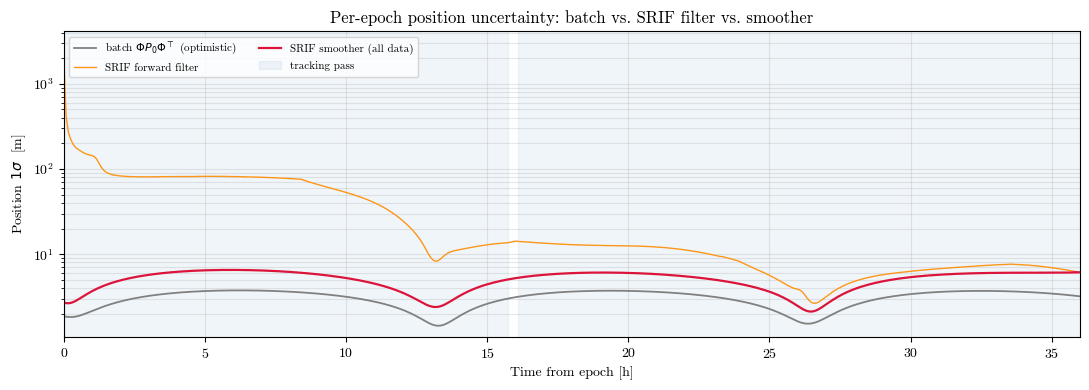

In [12]:
# Position 1-sigma over the arc for the three covariances. The batch curve (Phi P0
# Phi^T) is tight and nearly flat -- it only "knows" the epoch-0 solution. The SRIF
# *forward* filter grows without bound through the long, untracked apoapsis coasts
# (no future data yet). The *smoother* uses data on both sides of every epoch, so it
# stays bounded and dips at each tracking pass -- a realistic, honest uncertainty.
def pos_sigma(cov_flat):
    C = cov_flat.reshape(N, 6, 6)
    return np.sqrt(C[:, 0, 0] + C[:, 1, 1] + C[:, 2, 2])


fig, ax = plt.subplots(figsize=(11, 4))
ax.semilogy(t_hrs, pos_sigma(results.estimated_covariance), color="gray", lw=1.3,
            label=r"batch $\Phi P_0 \Phi^\top$ (optimistic)")
ax.semilogy(t_hrs, pos_sigma(results.srif_filtered_covariance), color="darkorange",
            lw=1.0, alpha=0.9, label="SRIF forward filter")
ax.semilogy(t_hrs, pos_sigma(results.srif_smoothed_covariance), color="crimson",
            lw=1.6, label="SRIF smoother (all data)")

# Shade epochs with at least one tracking measurement.
tracked = np.zeros(N, dtype=bool)
tracked[np.unique(results.obs_epoch_index)] = True
ax.fill_between(t_hrs, 1e-3, 1e5, where=tracked, color="steelblue", alpha=0.08,
                label="tracking pass", step="mid")

ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel(r"Position $1\sigma$  [m]")
ax.set_title("Per-epoch position uncertainty: batch vs. SRIF filter vs. smoother")
ax.set_xlim(0, t_hrs[-1])
ax.set_ylim(pos_sigma(results.srif_smoothed_covariance).min() * 0.5,
            pos_sigma(results.srif_filtered_covariance).max() * 2)
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Smoother Error and Covariance in the RTN Frame

Finally we repeat Section 7's RTN error plot, but overlay **both** covariance
envelopes: the batch $\pm1\sigma$ tube (`\Phi P_0 \Phi^\top`, dashed) and the
**smoother** $\pm1\sigma$ tube (shaded), together with the smoother's own estimate
error. The batch tube is the tighter of the two and the true error frequently
escapes it, especially through the apoapsis coasts — the visual signature of an
optimistic covariance. The smoother tube is process-noise-aware and **contains the
error** far more of the time, while remaining tight around the tracked periapsis
passes where the geometry is strong.

/var/folders/1f/_8g3y5td38n93nph4z3c5d4c0000gn/T/ipykernel_11490/659096228.py:54: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  plt.tight_layout()


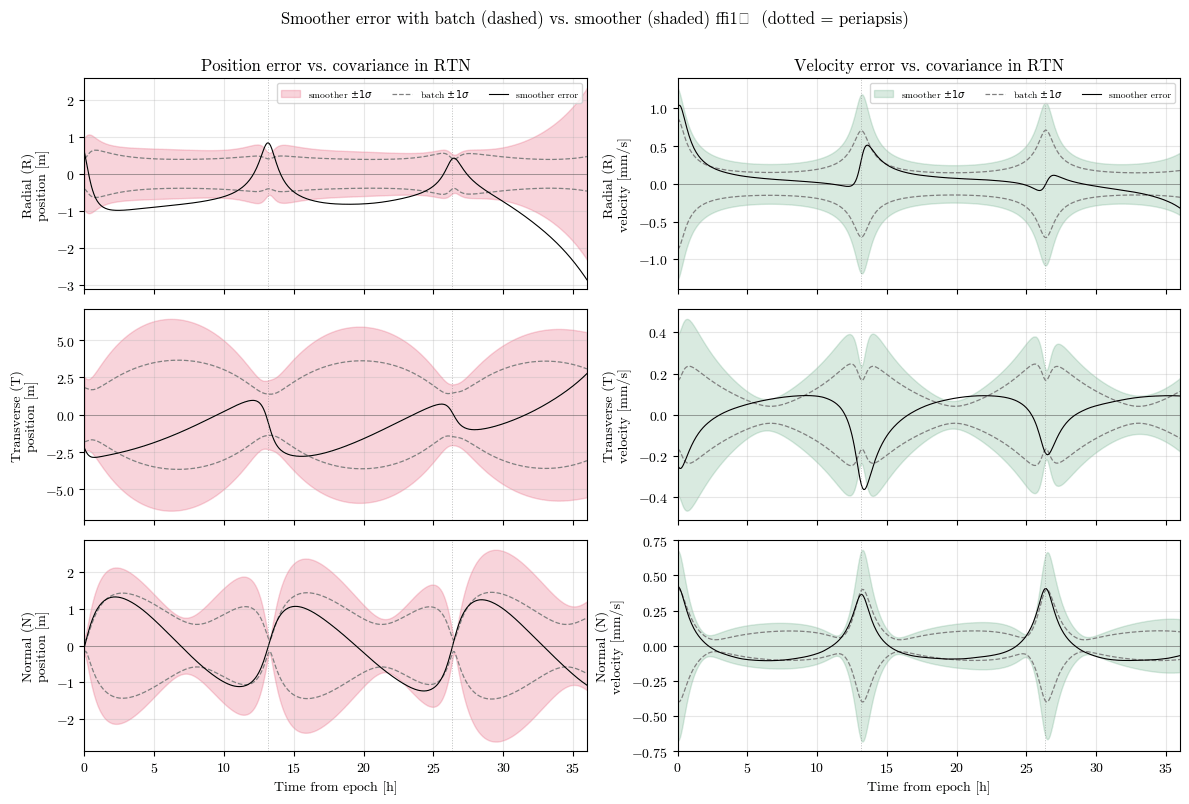

Position 1-sigma coverage (ideal 0.683):  batch 0.50   smoother 0.77


In [13]:
# Smoother estimate error (smoothed - truth) and covariance, rotated into the same
# RTN frame Q built from the true orbit in Section 7.
dpos_s_mci = results.srif_smoothed_state[:, :3] - results.truth_state[:, :3]
dvel_s_mci = results.srif_smoothed_state[:, 3:] - results.truth_state[:, 3:]
dpos_s_rtn = np.einsum("nij,nj->ni", Q, dpos_s_mci)
dvel_s_rtn = np.einsum("nij,nj->ni", Q, dvel_s_mci)

cov_s = results.srif_smoothed_covariance.reshape(-1, 6, 6)
Prr_s = np.einsum("nij,njk,nlk->nil", Q, cov_s[:, :3, :3], Q)
Pvv_s = np.einsum("nij,njk,nlk->nil", Q, cov_s[:, 3:, 3:], Q)
sig_pos_s_rtn = np.sqrt(np.diagonal(Prr_s, axis1=1, axis2=2))  # [N, 3] 1-sigma [m]
sig_vel_s_rtn = np.sqrt(np.diagonal(Pvv_s, axis1=1, axis2=2))  # [N, 3] 1-sigma [m/s]
# (sig_pos_rtn / sig_vel_rtn are the batch tubes from Section 7.)

labels = ["Radial (R)", "Transverse (T)", "Normal (N)"]
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
for k in range(3):
    axp = axes[k, 0]
    axp.fill_between(t_hrs, -sig_pos_s_rtn[:, k], sig_pos_s_rtn[:, k], color="crimson",
                     alpha=0.18, label=r"smoother $\pm1\sigma$")
    axp.plot(t_hrs, sig_pos_rtn[:, k], color="gray", ls="--", lw=0.9,
             label=r"batch $\pm1\sigma$")
    axp.plot(t_hrs, -sig_pos_rtn[:, k], color="gray", ls="--", lw=0.9)
    axp.plot(t_hrs, dpos_s_rtn[:, k], color="black", lw=0.8, label="smoother error")
    axp.axhline(0.0, color="k", lw=0.5, alpha=0.4)
    axp.set_ylabel(f"{labels[k]}\nposition [m]")
    axp.grid(True, alpha=0.3)

    axv = axes[k, 1]
    axv.fill_between(t_hrs, -sig_vel_s_rtn[:, k] * 1e3, sig_vel_s_rtn[:, k] * 1e3,
                     color="seagreen", alpha=0.18, label=r"smoother $\pm1\sigma$")
    axv.plot(t_hrs, sig_vel_rtn[:, k] * 1e3, color="gray", ls="--", lw=0.9,
             label=r"batch $\pm1\sigma$")
    axv.plot(t_hrs, -sig_vel_rtn[:, k] * 1e3, color="gray", ls="--", lw=0.9)
    axv.plot(t_hrs, dvel_s_rtn[:, k] * 1e3, color="black", lw=0.8, label="smoother error")
    axv.axhline(0.0, color="k", lw=0.5, alpha=0.4)
    axv.set_ylabel(f"{labels[k]}\nvelocity [mm/s]")
    axv.grid(True, alpha=0.3)

peri = np.where((r_mag[1:-1] < r_mag[:-2]) & (r_mag[1:-1] < r_mag[2:]))[0] + 1
for ax in axes.ravel():
    for p in peri:
        ax.axvline(t_hrs[p], color="gray", ls=":", lw=0.7, alpha=0.5)

axes[0, 0].set_title("Position error vs. covariance in RTN")
axes[0, 1].set_title("Velocity error vs. covariance in RTN")
axes[0, 0].legend(fontsize=7, loc="upper right", ncol=3)
axes[0, 1].legend(fontsize=7, loc="upper right", ncol=3)
for ax in axes[-1, :]:
    ax.set_xlabel("Time from epoch [h]")
    ax.set_xlim(0, t_hrs[-1])
fig.suptitle("Smoother error with batch (dashed) vs. smoother (shaded) ±1σ  "
             "(dotted = periapsis)", y=1.0)
plt.tight_layout()
plt.show()

# 1-sigma coverage: fraction of epochs whose per-axis error falls inside ±1-sigma
# (a well-calibrated Gaussian gives ~0.683). This is the RTN position summary.
batch_cov_pos = np.mean(np.abs(dpos_rtn) <= sig_pos_rtn)
smoo_cov_pos = np.mean(np.abs(dpos_s_rtn) <= sig_pos_s_rtn)
print(f"Position 1-sigma coverage (ideal 0.683):  batch {batch_cov_pos:.2f}   "
      f"smoother {smoo_cov_pos:.2f}")